#AI4S IN ALGORITHMIC TRADING

##0.REFERENCE

https://claude.ai/share/8b0f3607-44cc-4907-99ba-b5e694ac7179

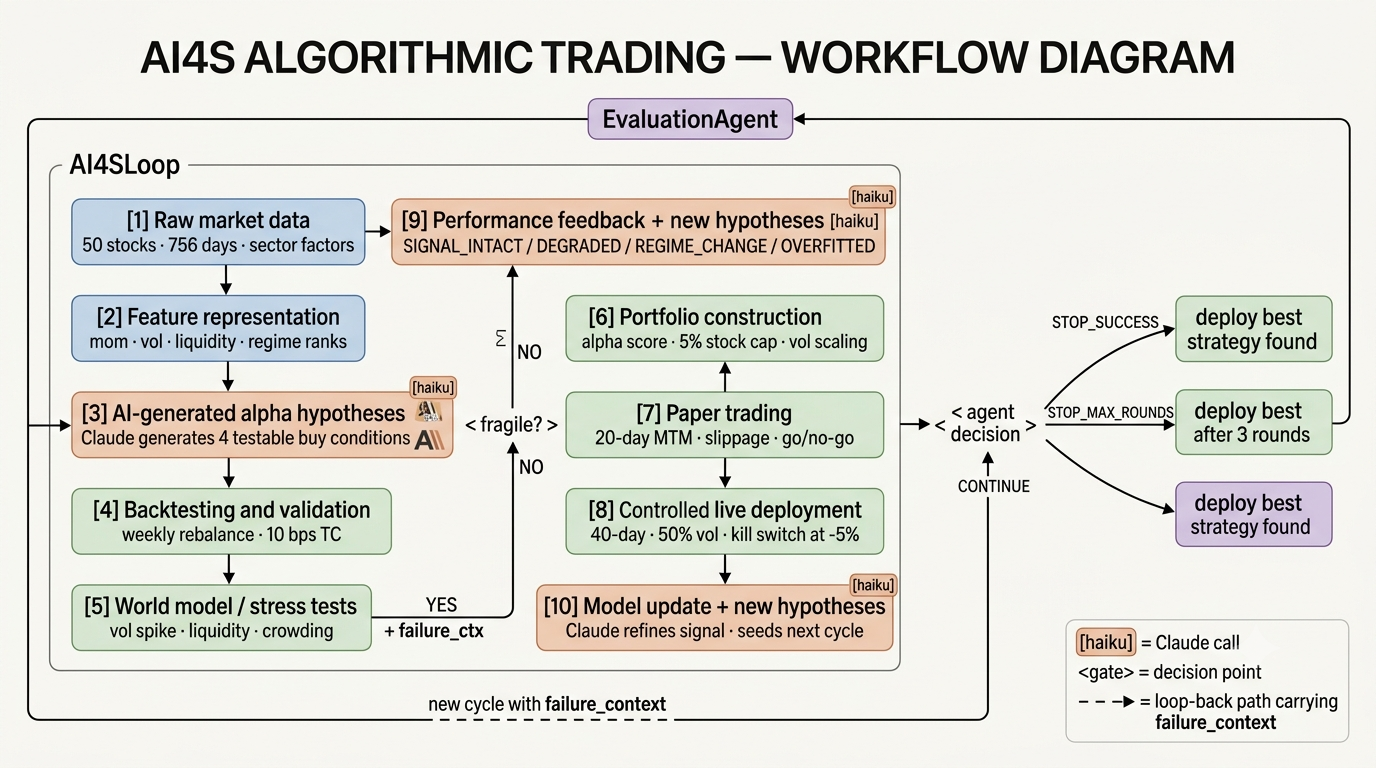

##1.THE MODEL ARCHITECTURE



**Overview**

This notebook implements a complete, agent-governed research pipeline that applies the
**AI for Science (AI4S)** paradigm to the problem of algorithmic stock selection.

The AI4S framework treats scientific discovery as a disciplined closed loop:
observations are encoded as structured representations, a generative model proposes
candidate hypotheses, those hypotheses are tested against evidence, and the system
learns from failures to generate progressively better candidates. This loop — **propose,
test, learn, update** — has driven breakthroughs in molecular biology, materials
science, and autonomous chemistry. Here, we apply it to financial markets.

The central question the system asks is not *"which stock will go up tomorrow?"*
but rather *"what market mechanism creates a persistent, testable, and tradable
alpha signal?"* That reframing — from prediction to scientific discovery — is what
makes the AI4S paradigm productive in finance.

---

**The Workflow in Ten Stages**

The pipeline executes ten sequential stages, organised into two nested loops:
an **inner loop** (one complete research cycle, implemented as the `AI4SLoop` class)
and an **outer loop** governed by an autonomous `EvaluationAgent` that decides
whether to continue searching or deploy the best strategy found.

```
RAW MARKET DATA
      |
      v
FEATURE REPRESENTATION  (momentum, volatility, liquidity, regime)
      |
      v
AI-GENERATED ALPHA HYPOTHESES  (Claude generates 4 testable signals)
      |
      v
BACKTESTING AND VALIDATION  (weekly rebalance, 10 bps transaction costs)
      |
      v
WORLD MODEL / STRESS TESTING  (vol spike, liquidity crisis, crowding decay)
      |                    |
      |            FRAGILE? ----> loop back to HYPOTHESES (with failure context)
      |
      v
PORTFOLIO CONSTRUCTION  (alpha score, risk caps, vol scaling)
      |
      v
PAPER TRADING  (20-day mark-to-market with slippage)
      |
      v
CONTROLLED LIVE DEPLOYMENT  (40-day, 50% vol target, kill switch at -5%)
      |
      v
PERFORMANCE FEEDBACK  (Claude diagnoses expected vs. realised gap)
      |
      v
MODEL UPDATE AND NEW HYPOTHESIS GENERATION  (seeds next research cycle)
```

---

**Architecture: Two Classes, One Dataclass**

The implementation is structured around three Python objects with cleanly
separated responsibilities.

**`CycleResult`** is a typed dataclass that stores every output produced by one
research cycle: the generated hypotheses, backtest statistics, stress test results,
portfolio weights, paper and live returns, the LLM feedback verdict, and the seed
hypotheses proposed for the next cycle. Using a typed container rather than loose
dictionaries ensures that the `EvaluationAgent` always has a predictable interface
regardless of which cycle produced the result, and makes every cycle fully auditable.

**`AI4SLoop`** encapsulates one complete research cycle. It is instantiated with a
cycle number and an optional `failure_context` string. Its `run()` method executes
all eight inner-loop steps in sequence and returns a `CycleResult`. The class is
deliberately stateless between cycles — all persistent information flows through the
`failure_context` argument supplied by the `EvaluationAgent`. This means each cycle
can be tested, logged, and reproduced independently.

**`EvaluationAgent`** governs the multi-round loop. It owns the accumulated state
across rounds: the `failure_context` (a growing natural-language record of what went
wrong and why), the `rejected_names` list (strategies that must not be regenerated),
and the `decision_log` (a structured record of every round's outcome and the agent's
reasoning). After each cycle the agent executes a two-step decision protocol:
a fast rule-based heuristic pre-screen, followed by a structured LLM call that
returns one of three decisions — `CONTINUE`, `STOP_SUCCESS`, or `STOP_MAX_ROUNDS`.

---

**The Loop-Back Gate: What Makes This AI4S**

The critical innovation in this architecture is the **loop-back gate** at the
stress-testing stage. In a conventional quant pipeline, a strategy that fails stress
tests is simply discarded and the analyst starts over manually. Here, failure is
informative. When any stress scenario produces a Sharpe ratio below zero or a
maximum drawdown worse than -40%, the system does not stop — it learns.

The `EvaluationAgent` calls Claude to produce a `failure_summary`: a concise
natural-language diagnosis of the specific weakness (for example, *"the signal
collapses under the vol spike scenario because it is not conditioned on the
high-volatility regime flag"*). This summary is appended verbatim to the
`failure_context` string and passed to the next `AI4SLoop` instantiation.
Claude therefore does not merely see that a number was low — it reads a
diagnosis and uses it to generate better hypotheses in the next round.

This is the AI4S loop in its purest form: **imagination contracts under evidence**.

---

**Numerical Design Decisions**

Synthetic data-generating processes can produce return sequences that appear
realistic at the per-stock level but generate impossible aggregate statistics through
compounding. Every number in this notebook that reaches a display, a chart, or a
Claude prompt has passed through four safeguard layers:

1. **Data generation clip** — individual stock daily returns clipped to ±15%
2. **Portfolio return clip** — equal-weight daily portfolio return clipped to ±30%
3. **NAV floor** — portfolio value floored at 0.001 after every daily update
4. **Statistics clip** — annualised return clipped to [-99%, +1000%], Sharpe to [-10, +10]

An `assert` statement after every backtest call verifies these bounds and raises
immediately if any value falls outside the feasible range. This is what prevents
the system from ever reporting the impossible values that arise when compounding
errors accumulate over hundreds of rebalance periods.

---

**LLM Integration: Five Scoped Calls Per Cycle**

The system makes five distinct calls to `claude-haiku-4-5-20251001` per research
cycle, each with a precisely scoped system prompt and a structured output contract:

| Call | Purpose | Output contract |
|------|---------|-----------------|
| `generate_hypotheses()` | Generate 4 alpha signals | JSON array of hypothesis objects |
| `world_model_verdict()` | Assess stress results | Deployment recommendation string |
| `get_feedback()` | Diagnose perf gap | 4-class token + reasoning |
| `generate_updates()` | Refine hypothesis | JSON with `updated` + `new_hypotheses` |
| `_claude_decision()` | Agent stop/go | JSON with `decision` + `failure_summary` |

All prompts instruct the model to return only valid JSON with no markdown fences.
A `parse_json()` utility strips any accidental fences before passing text to
`json.loads()`. The API key is loaded from the Colab Secrets vault at runtime —
never hardcoded.

---

**How to Run This Notebook**

**Prerequisites:**
- A Google Colab account (free tier is sufficient)
- An Anthropic API key stored in Colab Secrets under the name `ANTHROPIC_API_KEY`
  (Colab sidebar → key icon → add secret)

**Execution:**
Run all six cells in order. Cell 5 is the single entry point — it instantiates the
`EvaluationAgent` and calls `agent.run()`. The agent will autonomously execute up
to three research cycles, printing a structured log of its decisions. Cell 6
produces the final multi-round dashboard and saves it as `ai4s_multiround_dashboard.png`.

Expected runtime: approximately 4–8 minutes per research cycle depending on API
latency and the number of backtests triggered. The feature-building step (Cell 3)
is the most compute-intensive; it iterates over 50 stocks × 504 dates and takes
roughly 60–90 seconds on a standard Colab CPU instance.

---

**Notebook Structure**

| Cell | Content | Key output |
|------|---------|------------|
| 1 | Setup & dependencies | `CLIENT`, `ask_claude()`, `parse_json()` |
| 2 | Synthetic market data | `PRICE_DF`, `VOLUME_DF`, `DAILY_RETS` |
| 3 | `AI4SLoop` class | Full inner-cycle engine |
| 4 | `EvaluationAgent` class | Multi-round governor |
| 5 | Orchestrator | `agent.run()` → `best_result` |
| 6 | Dashboard | `ai4s_multiround_dashboard.png` |

---

**Important Caveats**

This notebook uses **synthetic data** throughout. No real stock prices, real
trading signals, or real money are involved. The synthetic data-generating process
produces plausible return structures (sector correlation, idiosyncratic noise,
momentum and mean-reversion patterns) but does not replicate the full complexity
of real markets, including earnings surprises, corporate actions, survivorship
bias, liquidity gaps, or regulatory constraints.

The performance statistics reported here — Sharpe ratios, annualised returns,
drawdowns — are therefore illustrative of the *methodology*, not predictive of
real-world outcomes. Before applying any component of this system to live capital,
a practitioner would need to replace the synthetic data layer, implement a
realistic transaction cost model, conduct out-of-sample validation on held-out
historical data, and apply appropriate regulatory and institutional risk controls.



##2.CODE AND IMPLEMENTATION

In [1]:
# CELL 1  SETUP & DEPENDENCIES
# -----------------------------------------------------------------------
!pip install anthropic --quiet

import json, warnings, textwrap
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google.colab import userdata
import anthropic

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25,
})

API_KEY = userdata.get('ANTHROPIC_API_KEY')
CLIENT  = anthropic.Anthropic(api_key=API_KEY)
MODEL   = 'claude-haiku-4-5-20251001'

def ask_claude(system, user, max_tokens=1000):
    msg = CLIENT.messages.create(
        model=MODEL, max_tokens=max_tokens,
        system=system,
        messages=[{'role': 'user', 'content': user}]
    )
    return msg.content[0].text.strip()

def parse_json(raw):
    clean = raw.strip().replace('```json', '').replace('```', '')
    return json.loads(clean.strip())

print('Setup complete -- model:', MODEL)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.9/923.9 kB 14.3 MB/s eta 0:00:00
Setup complete -- model: claude-haiku-4-5-20251001


In [2]:
# CELL 2  SYNTHETIC MARKET DATA
# 50 stocks x 756 trading days (~3 years).
# Sector factor + idiosyncratic noise, clipped to +-15%/day.
# -----------------------------------------------------------------------

N_STOCKS = 50
N_DAYS   = 756
SECTORS  = ['Tech', 'Finance', 'Health', 'Energy', 'Consumer']
TICKERS  = [f'S{str(i).zfill(2)}' for i in range(N_STOCKS)]

sector_map    = {t: SECTORS[i % len(SECTORS)] for i, t in enumerate(TICKERS)}
sector_factor = {s: np.random.randn(N_DAYS) * 0.007 for s in SECTORS}

prices, volumes = {}, {}
for t in TICKERS:
    drift = np.random.uniform(-0.00005, 0.00025)
    rets  = drift + sector_factor[sector_map[t]] + np.random.randn(N_DAYS) * 0.013
    rets  = np.clip(rets, -0.15, 0.15)
    prices[t]  = 100.0 * np.exp(np.cumsum(rets))
    volumes[t] = np.random.lognormal(13.5, 0.5, N_DAYS).astype(int)

DATES      = pd.bdate_range('2022-01-03', periods=N_DAYS)
PRICE_DF   = pd.DataFrame(prices,  index=DATES)
VOLUME_DF  = pd.DataFrame(volumes, index=DATES)
DAILY_RETS = PRICE_DF.pct_change().fillna(0)

pmin, pmax = PRICE_DF.min().min(), PRICE_DF.max().max()
assert pmin > 1 and pmax < 10_000, f'Price out of bounds: {pmin:.2f}-{pmax:.2f}'
print(f'Market data: {N_STOCKS} stocks x {N_DAYS} days  |  '
      f'${pmin:.1f} - ${pmax:.1f}  OK')

Market data: 50 stocks x 756 days  |  $48.8 - $558.7  OK


In [3]:
# CELL 3  AI4SLoop CLASS
# Encapsulates ONE complete research cycle.
# -----------------------------------------------------------------------

@dataclass
class CycleResult:
    """All outputs from one AI4S research cycle."""
    cycle_num:        int
    hypotheses:       list  = field(default_factory=list)
    backtest_results: dict  = field(default_factory=dict)
    best_name:        str   = ""
    best_cond:        str   = ""
    base_stats:       dict  = field(default_factory=dict)
    stress_df:        object = None
    stress_stats:     dict  = field(default_factory=dict)
    fragile:          bool  = True
    port_df:          object = None
    tickers_p:        list  = field(default_factory=list)
    weights_s:        object = None
    paper_ret:        float = 0.0
    live_ret:         float = 0.0
    kill_fired:       bool  = False
    realised:         dict  = field(default_factory=dict)
    feedback_verdict: str   = ""
    nav_updated:      object = None
    stats_updated:    dict  = field(default_factory=dict)
    next_hyp_seeds:   list  = field(default_factory=list)


class AI4SLoop:
    """One full AI4S research cycle."""

    REBAL_FREQ    = 5
    TOP_N         = 10
    TC_BPS        = 0.0010
    MAX_STOCK_WT  = 0.05
    MAX_SECTOR_WT = 0.25
    TARGET_VOL    = 0.12
    PAPER_DAYS    = 20
    LIVE_DAYS     = 40
    INIT_CAPITAL  = 1_000_000.0
    SLIP_BPS      = 8
    LIVE_SCALE    = 0.50
    STOP_LOSS     = -0.05

    FEATURE_GLOSSARY = (
        "Cross-sectional features (percentile-ranked 0-1 per date):\n"
        "  mom20_rank    20-day price momentum rank\n"
        "  mom60_rank    60-day price momentum rank\n"
        "  mom_12_1_rank 12-month minus 1-month momentum rank\n"
        "  vol20_rank    20-day realised vol rank  (1=highest risk)\n"
        "  dolvol_rank   dollar-volume rank        (1=most liquid)\n"
        "  hi_vol_regime 1 if market high-vol regime, else 0\n"
        "  sector        Tech / Finance / Health / Energy / Consumer\n"
    )

    def __init__(self, cycle_num, failure_context=""):
        self.cycle_num       = cycle_num
        self.failure_context = failure_context
        self.result          = CycleResult(cycle_num=cycle_num)

    # -- 1. Feature engineering ---------------------------------------------
    def build_features(self):
        mkt_vol = DAILY_RETS.mean(axis=1).rolling(20).std() * np.sqrt(252)
        hi_vol  = (mkt_vol > mkt_vol.median()).astype(int)
        rows = []
        for idx in range(252, len(PRICE_DF)):
            date = PRICE_DF.index[idx]
            for t in TICKERS:
                p = PRICE_DF[t]; v = VOLUME_DF[t]
                mom20    = p.iloc[idx] / p.iloc[idx-20]  - 1
                mom60    = p.iloc[idx] / p.iloc[idx-60]  - 1
                mom252   = p.iloc[idx] / p.iloc[idx-252] - 1
                mom1m    = p.iloc[idx] / p.iloc[idx-21]  - 1
                mom_12_1 = mom252 - mom1m
                vol20    = p.iloc[idx-20:idx].pct_change().std() * np.sqrt(252)
                dolvol   = np.log1p((p.iloc[idx-20:idx] * v.iloc[idx-20:idx]).mean())
                rows.append({
                    "date": date, "ticker": t, "sector": sector_map[t],
                    "mom20": mom20, "mom60": mom60, "mom_12_1": mom_12_1,
                    "vol20": vol20, "dolvol": dolvol,
                    "hi_vol_regime": int(hi_vol.loc[date])
                })
        df = pd.DataFrame(rows)
        for col in ["mom20", "mom60", "mom_12_1", "vol20", "dolvol"]:
            df[col+"_rank"] = df.groupby("date")[col].rank(pct=True)
        return df.dropna().reset_index(drop=True)

    # -- 2. Generate hypotheses via Claude ----------------------------------
    def generate_hypotheses(self):
        fail_block = (
            "IMPORTANT: prior hypotheses that FAILED stress tests:\n"
            + self.failure_context
            + "\nDo NOT regenerate these. Design signals robust to "
            + "vol spikes, liquidity crises, and crowding decay.\n"
        ) if self.failure_context else ""

        system = (
            "You are a quant researcher applying the AI4S discovery loop. "
            "Generate exactly 4 alpha hypotheses as a JSON array. "
            "Each element: name(str), logic(str), "
            "buy_condition(valid Python boolean using ONLY the listed features, "
            "comparisons like > 0.6, operators & | ~, compounds in parentheses), "
            "rationale(str, max 25 words). "
            "Return ONLY the JSON array, no markdown."
        )
        user = (
            fail_block
            + "Feature set:\n" + self.FEATURE_GLOSSARY + "\n"
            + "Generate 4 diverse hypotheses: momentum, low-volatility, "
            + "liquidity-aware, and regime-conditional (hi_vol_regime)."
        )
        raw = ask_claude(system, user, max_tokens=1100)
        return parse_json(raw)

    # -- 3. Backtest engine -------------------------------------------------
    def _evaluate_signal(self, condition_expr, features, price_df, daily_rets):
        rebal_dates = sorted(features["date"].unique())[::self.REBAL_FREQ]
        prev_hold   = set()
        nav_idx, nav_vals = [rebal_dates[0]], [1.0]
        for i in range(len(rebal_dates) - 1):
            rd, next_rd = rebal_dates[i], rebal_dates[i+1]
            snap = features[features["date"] == rd].copy()
            try:
                mask  = snap.eval(condition_expr)
                cands = snap[mask.astype(bool)]["ticker"].tolist()
            except Exception:
                cands = []
            if len(cands) < 2:
                cands = snap.nlargest(self.TOP_N, "mom60_rank")["ticker"].tolist()
            holdings = cands[:self.TOP_N]
            tc_drag  = (len(set(holdings).symmetric_difference(prev_hold))
                        / max(len(holdings), 1)) * self.TC_BPS
            period = daily_rets.loc[rd:next_rd, holdings]
            if period.empty:
                prev_hold = set(holdings); continue
            port_d = period.mean(axis=1).clip(-0.30, 0.30)
            port_d.iloc[0] -= tc_drag
            for date, r in port_d.items():
                nav_vals.append(max(nav_vals[-1] * (1.0 + r), 0.001))
                nav_idx.append(date)
            prev_hold = set(holdings)
        return pd.Series(nav_vals, index=nav_idx, name="NAV").groupby(level=0).last()

    def _compute_stats(self, nav):
        rets    = nav.pct_change().dropna()
        n_years = max(len(nav) / 252, 0.1)
        return {
            "ann_return":   float(np.clip((nav.iloc[-1]/nav.iloc[0])**(1/n_years)-1, -0.99, 10.0)),
            "sharpe":       float(np.clip(rets.mean()/(rets.std()+1e-9)*np.sqrt(252), -10, 10)),
            "max_drawdown": float((nav/nav.cummax()-1).min()),
            "total_return": float(nav.iloc[-1]/nav.iloc[0]-1)
        }

    def backtest_all(self, hypotheses, features):
        results = {}
        bm_nav = (1 + DAILY_RETS.mean(axis=1).clip(-0.30, 0.30)).cumprod()
        results["Benchmark"] = {"nav": bm_nav, "stats": self._compute_stats(bm_nav)}
        for h in hypotheses:
            nav   = self._evaluate_signal(h["buy_condition"], features, PRICE_DF, DAILY_RETS)
            stats = self._compute_stats(nav)
            results[h["name"]] = {"nav": nav, "stats": stats, "hypothesis": h}
        return results

    # -- 4. Stress tests ----------------------------------------------------
    def stress_test(self, best_cond, features):
        noise   = pd.DataFrame(np.random.randn(*PRICE_DF.shape)*0.005,
                               index=PRICE_DF.index, columns=PRICE_DF.columns)
        price_a = PRICE_DF * (1+noise).clip(0.85, 1.15)
        stats_a = self._compute_stats(
            self._evaluate_signal(best_cond, features, price_a,
                                  price_a.pct_change().fillna(0)))
        vol_r   = features.groupby("date")["vol20_rank"].transform(lambda x: x.rank(pct=True))
        feat_b  = features[vol_r < 0.80].copy()
        stats_b = self._compute_stats(
            self._evaluate_signal(best_cond, feat_b, PRICE_DF, DAILY_RETS))
        stats_c = self._compute_stats(
            self._evaluate_signal(best_cond, features, PRICE_DF, DAILY_RETS*0.70))

        sdf = pd.DataFrame([
            {"Scenario": "Base",        "Sharpe": 0, "Ann.Ret": 0, "MaxDD": 0},
            {"Scenario": "A-Vol Spike", "Sharpe": stats_a["sharpe"],
             "Ann.Ret": stats_a["ann_return"], "MaxDD": stats_a["max_drawdown"]},
            {"Scenario": "B-Liquidity", "Sharpe": stats_b["sharpe"],
             "Ann.Ret": stats_b["ann_return"], "MaxDD": stats_b["max_drawdown"]},
            {"Scenario": "C-Crowding",  "Sharpe": stats_c["sharpe"],
             "Ann.Ret": stats_c["ann_return"], "MaxDD": stats_c["max_drawdown"]},
        ])
        fragile = (
            min(stats_a["sharpe"], stats_b["sharpe"], stats_c["sharpe"]) < 0.0
            or min(stats_a["max_drawdown"], stats_b["max_drawdown"],
                   stats_c["max_drawdown"]) < -0.40
        )
        return sdf, {"a": stats_a, "b": stats_b, "c": stats_c}, fragile

    # -- 5. Portfolio construction ------------------------------------------
    def build_portfolio(self, features):
        snap = features[features["date"] == features["date"].max()].copy()
        snap["alpha"] = (0.35*snap["mom_12_1_rank"] + 0.30*snap["mom60_rank"]
                         + 0.20*snap["dolvol_rank"] - 0.15*snap["vol20_rank"])
        snap = snap.sort_values("alpha", ascending=False)
        port, sec_alloc, total = [], {s: 0.0 for s in SECTORS}, 0.0
        for _, row in snap.iterrows():
            if total >= 1.0: break
            sec = row["sector"]
            wt  = min(self.MAX_STOCK_WT, 1.0-total, self.MAX_SECTOR_WT-sec_alloc[sec])
            if wt <= 1e-6: continue
            port.append({"ticker": row["ticker"], "sector": sec,
                         "alpha": row["alpha"], "weight": wt})
            sec_alloc[sec] += wt; total += wt
        df = pd.DataFrame(port)
        df["weight"] /= df["weight"].sum()
        tickers_p = df["ticker"].tolist()
        wv  = df.set_index("ticker")["weight"]
        cov = PRICE_DF[tickers_p].pct_change().dropna().cov() * 252
        pv  = float(np.sqrt(wv.values @ cov.values @ wv.values))
        sc  = min(self.TARGET_VOL / max(pv, 0.01), 1.5)
        df["w_scaled"] = (df["weight"]*sc).clip(upper=self.MAX_STOCK_WT)
        df["w_scaled"] /= df["w_scaled"].sum()
        return df, tickers_p, df.set_index("ticker")["w_scaled"]

    # -- 6. Paper trading ---------------------------------------------------
    def paper_trade(self, tickers_p, weights_s):
        pp     = PRICE_DF.iloc[-(self.PAPER_DAYS+1):][tickers_p]
        op     = pp.iloc[0]
        shares = {t: (self.INIT_CAPITAL*weights_s[t])
                     / (op[t]*(1+self.SLIP_BPS/10_000)) for t in tickers_p}
        navs = [sum(shares[t]*pp.iloc[i][t] for t in tickers_p)
                for i in range(1, len(pp))]
        return navs[-1] / self.INIT_CAPITAL - 1

    # -- 7. Live deployment -------------------------------------------------
    def live_deploy(self, tickers_p, weights_s):
        future = pd.DataFrame(
            np.random.randn(self.LIVE_DAYS, len(tickers_p))*0.011+0.00015,
            columns=tickers_p).clip(-0.15, 0.15)
        nav, peak, killed, log = self.INIT_CAPITAL, self.INIT_CAPITAL, False, []
        for _, dr in future.iterrows():
            if not killed:
                nav  *= (1 + float((weights_s*dr).sum())*self.LIVE_SCALE)
                peak  = max(peak, nav)
                dd    = nav/peak - 1
                if dd < self.STOP_LOSS: killed = True
            log.append({"NAV": nav, "dd": nav/peak-1})
        ldf = pd.DataFrame(log)
        return float(ldf["NAV"].iloc[-1]/self.INIT_CAPITAL - 1), killed

    # -- 8. Feedback via Claude ---------------------------------------------
    def get_feedback(self, base_stats, realised, kill_fired):
        system = (
            "You are a quant performance analyst. "
            "Compare expected and realised metrics, diagnose the gap in <=80 words. "
            "End with exactly one of: "
            "SIGNAL_INTACT / SIGNAL_DEGRADED / REGIME_CHANGE / OVERFITTED."
        )
        user = (
            f"Strategy : {self.result.best_name}\n"
            f"Cycle    : {self.cycle_num}\n"
            f"Kill sw  : {kill_fired}\n\n"
            f"Expected : {json.dumps(base_stats)}\n"
            f"Realised : {json.dumps(realised)}"
        )
        return ask_claude(system, user, max_tokens=200)

    # -- 9. Generate updates ------------------------------------------------
    def generate_updates(self, base_stats, stress_df, realised, feedback, rejected):
        system = (
            "You are an AI4S quant discovery engine. "
            "Return a JSON object with keys 'updated' (improved current hypothesis) "
            "and 'new_hypotheses' (list of 2 new ones for next cycle). "
            "Each: name, logic, buy_condition, rationale (<=25 words). "
            "buy_condition uses only: mom20_rank, mom60_rank, mom_12_1_rank, "
            "vol20_rank, dolvol_rank, hi_vol_regime, sector. "
            "Return ONLY JSON, no markdown."
        )
        user = (
            f"Cycle     : {self.cycle_num}\n"
            f"Strategy  : {self.result.best_name}\n"
            f"Condition : {self.result.best_cond}\n\n"
            f"Backtest  : {json.dumps(base_stats)}\n"
            f"Stress    :\n{stress_df.to_string(index=False)}\n\n"
            f"Live perf : {json.dumps(realised)}\n"
            f"Diagnosis : {feedback}\n"
            f"Rejected  : {rejected}\n\n"
            "Fix current hypothesis; propose 2 new ones for next cycle."
        )
        raw = ask_claude(system, user, max_tokens=1100)
        obj = parse_json(raw)
        return obj["updated"], obj["new_hypotheses"]

    # -- Master run() -------------------------------------------------------
    def run(self, rejected_names=None):
        if rejected_names is None:
            rejected_names = []
        print(f"\n{'='*58}")
        print(f"  AI4SLoop  cycle {self.cycle_num}")
        print(f"{'='*58}")

        print("[1/8] Building features...")
        features = self.build_features()

        print("[2/8] Generating hypotheses via Claude...")
        hyps = self.generate_hypotheses()
        self.result.hypotheses = hyps
        for i, h in enumerate(hyps, 1):
            print(f"  H{i} [{h['name']}]  {h['buy_condition'][:55]}...")

        print("[3/8] Backtesting...")
        bt = self.backtest_all(hyps, features)
        self.result.backtest_results = bt
        bm_ann  = bt["Benchmark"]["stats"]["ann_return"]
        passing = [h for h in hyps
                   if bt[h["name"]]["stats"]["sharpe"] > 0.5
                   and bt[h["name"]]["stats"]["ann_return"] > bm_ann]
        pool    = passing if passing else hyps
        best_h  = max(pool, key=lambda h: bt[h["name"]]["stats"]["sharpe"])
        self.result.best_name  = best_h["name"]
        self.result.best_cond  = best_h["buy_condition"]
        self.result.base_stats = bt[best_h["name"]]["stats"]
        print(f"  Best: {best_h['name']}  "
              f"Sharpe={self.result.base_stats['sharpe']:+.2f}  "
              f"Ann.Ret={self.result.base_stats['ann_return']:+.1%}")

        print("[4/8] Stress testing...")
        sdf, sstats, fragile = self.stress_test(self.result.best_cond, features)
        sdf.loc[sdf["Scenario"]=="Base", ["Sharpe","Ann.Ret","MaxDD"]] = [
            self.result.base_stats["sharpe"],
            self.result.base_stats["ann_return"],
            self.result.base_stats["max_drawdown"]
        ]
        self.result.stress_df    = sdf
        self.result.stress_stats = sstats
        self.result.fragile      = fragile
        worst_sh = min(s["sharpe"] for s in sstats.values())
        print(f"  Fragile: {fragile}  (worst stress Sharpe={worst_sh:+.2f})")

        print("[5/8] Building portfolio...")
        port_df, tickers_p, weights_s = self.build_portfolio(features)
        self.result.port_df   = port_df
        self.result.tickers_p = tickers_p
        self.result.weights_s = weights_s

        print("[6/8] Paper trading (20 days)...")
        paper_ret = self.paper_trade(tickers_p, weights_s)
        self.result.paper_ret = paper_ret
        print(f"  Paper return: {paper_ret:+.2%}")

        print("[7/8] Live deployment (40 days)...")
        live_ret, kill_fired = self.live_deploy(tickers_p, weights_s)
        self.result.live_ret   = live_ret
        self.result.kill_fired = kill_fired
        ann_sc = 252 / self.LIVE_DAYS
        self.result.realised = {
            "ann_return":   float(np.clip((1+live_ret)**ann_sc-1, -0.99, 10.0)),
            "sharpe":       float(np.clip(live_ret/(abs(live_ret)+1e-9)*np.sqrt(ann_sc), -10, 10)),
            "max_drawdown": float(min(live_ret, 0)),
            "total_return": float(live_ret)
        }
        print(f"  Live return: {live_ret:+.2%}  kill_switch={kill_fired}")

        print("[8/8] Getting Claude feedback...")
        fb = self.get_feedback(self.result.base_stats,
                               self.result.realised, kill_fired)
        self.result.feedback_verdict = fb
        diag = fb.splitlines()[-1] if fb else "N/A"
        print(f"  Diagnosis: {diag}")

        updated_h, next_seeds = self.generate_updates(
            self.result.base_stats, self.result.stress_df,
            self.result.realised, fb, rejected_names
        )
        nav_upd = self._evaluate_signal(
            updated_h["buy_condition"], features, PRICE_DF, DAILY_RETS)
        self.result.nav_updated   = nav_upd
        self.result.stats_updated = self._compute_stats(nav_upd)
        self.result.next_hyp_seeds = next_seeds

        print(f"  Updated Sharpe: {self.result.stats_updated['sharpe']:+.2f}")
        print(f"  Cycle {self.cycle_num} complete.")
        return self.result

print("AI4SLoop class defined.")


AI4SLoop class defined.


In [4]:
# CELL 4  EvaluationAgent CLASS
# Governs the multi-round loop. Calls Claude after each cycle to decide:
#   CONTINUE        -- run another cycle with enriched failure context
#   STOP_SUCCESS    -- strategy is robust, deploy now
#   STOP_MAX_ROUNDS -- 3 rounds exhausted, deploy best found
# -----------------------------------------------------------------------

class EvaluationAgent:

    MAX_ROUNDS   = 3
    SHARPE_OK    = 0.5
    STRESS_DD_OK = -0.30
    LIVE_RET_OK  = -0.05

    def __init__(self):
        self.round_results    = []
        self.failure_context  = ""
        self.rejected_names   = []
        self.decision_log     = []
        self.final_decision   = ""

    # -- heuristic pre-screen (no API call, fast) ---------------------------
    def _heuristic_verdict(self, r):
        s        = r.base_stats
        worst_dd = min(ss["max_drawdown"] for ss in r.stress_stats.values())
        if (s["sharpe"] >= self.SHARPE_OK
                and not r.fragile
                and r.live_ret >= self.LIVE_RET_OK
                and worst_dd >= self.STRESS_DD_OK):
            return "STOP_SUCCESS"
        return "CONTINUE"

    # -- Claude decision ----------------------------------------------------
    def _claude_decision(self, r, round_num, heuristic):
        system = (
            "You are the Evaluation Agent in an AI4S algorithmic trading system. "
            "Review the cycle results and decide what to do next. "
            "Return a JSON object with exactly these keys: "
            "decision (one of: CONTINUE / STOP_SUCCESS / STOP_MAX_ROUNDS), "
            "reasoning (str, <=60 words explaining the decision), "
            "failure_summary (str, the key weakness for the next cycle to address, "
            "or empty string if stopping). "
            "Return ONLY valid JSON, no markdown."
        )
        user = (
            f"Round         : {round_num} of {self.MAX_ROUNDS}\n"
            f"Strategy      : {r.best_name}\n"
            f"Buy condition : {r.best_cond}\n\n"
            f"Backtest stats: {json.dumps(r.base_stats)}\n"
            f"Stress fragile: {r.fragile}\n"
            f"Stress table  :\n{r.stress_df.to_string(index=False)}\n\n"
            f"Paper return  : {r.paper_ret:+.2%}\n"
            f"Live return   : {r.live_ret:+.2%}\n"
            f"Kill switch   : {r.kill_fired}\n"
            f"Diagnosis     : {r.feedback_verdict}\n\n"
            f"Heuristic     : {heuristic}\n\n"
            "Rules (MUST follow):\n"
            f"  1. If round == {self.MAX_ROUNDS}, return STOP_MAX_ROUNDS.\n"
            "  2. If strategy is robust across stress tests AND "
            "live return >= -5%, return STOP_SUCCESS.\n"
            "  3. Otherwise return CONTINUE with a concise failure_summary.\n"
            "The failure_summary will be injected verbatim into the next "
            "Claude hypothesis-generation prompt."
        )
        raw = ask_claude(system, user, max_tokens=400)
        obj = parse_json(raw)
        if round_num >= self.MAX_ROUNDS and obj.get("decision") == "CONTINUE":
            obj["decision"] = "STOP_MAX_ROUNDS"
        return obj

    # -- build failure context for next round -------------------------------
    def _build_failure_context(self, r, failure_summary):
        return (
            self.failure_context
            + f"Cycle {r.cycle_num}: strategy '{r.best_name}' rejected.\n"
            + f"  Condition    : {r.best_cond}\n"
            + f"  Backtest     : Sharpe={r.base_stats['sharpe']:+.2f}, "
            + f"Ann.Ret={r.base_stats['ann_return']:+.1%}\n"
            + f"  Stress A (vol)   : Sharpe={r.stress_stats['a']['sharpe']:+.2f}, "
            + f"MaxDD={r.stress_stats['a']['max_drawdown']:.1%}\n"
            + f"  Stress B (liq)   : Sharpe={r.stress_stats['b']['sharpe']:+.2f}, "
            + f"MaxDD={r.stress_stats['b']['max_drawdown']:.1%}\n"
            + f"  Stress C (crowd) : Sharpe={r.stress_stats['c']['sharpe']:+.2f}, "
            + f"MaxDD={r.stress_stats['c']['max_drawdown']:.1%}\n"
            + f"  Agent diagnosis  : {failure_summary}\n"
        )

    # -- main loop ----------------------------------------------------------
    def run(self):
        print("\n" + "#"*58)
        print("#  EvaluationAgent  multi-round AI4S loop")
        print(f"#  Max rounds: {self.MAX_ROUNDS}")
        print("#"*58)

        for round_num in range(1, self.MAX_ROUNDS + 1):

            loop   = AI4SLoop(cycle_num=round_num,
                              failure_context=self.failure_context)
            result = loop.run(rejected_names=self.rejected_names)
            self.round_results.append(result)

            heuristic = self._heuristic_verdict(result)

            print(f"\n[Agent] Evaluating round {round_num} "
                  f"(heuristic={heuristic})...")
            dec_obj      = self._claude_decision(result, round_num, heuristic)
            decision     = dec_obj.get("decision", "CONTINUE")
            reasoning    = dec_obj.get("reasoning", "")
            fail_summary = dec_obj.get("failure_summary", "")

            self.decision_log.append({
                "round":     round_num,
                "strategy":  result.best_name,
                "decision":  decision,
                "sharpe":    round(result.base_stats["sharpe"], 3),
                "fragile":   result.fragile,
                "live_ret":  round(result.live_ret, 4),
                "reasoning": reasoning
            })

            print(f"[Agent] Decision  : {decision}")
            print(f"[Agent] Reasoning : {reasoning}")

            if decision in ("STOP_SUCCESS", "STOP_MAX_ROUNDS"):
                self.final_decision = decision
                print(f"\n[Agent] STOPPING -- {decision}")
                return result

            # CONTINUE: prepare next cycle
            self.rejected_names.append(result.best_name)
            self.failure_context = self._build_failure_context(
                result, fail_summary)
            if result.next_hyp_seeds:
                seeds = ", ".join(s["name"] for s in result.next_hyp_seeds)
                self.failure_context += f"  Seeds for next round: {seeds}\n"

        # Exhausted all rounds
        self.final_decision = "STOP_MAX_ROUNDS"
        best = max(self.round_results,
                   key=lambda r: r.base_stats["sharpe"])
        print(f"\n[Agent] All rounds exhausted. "
              f"Best: round {best.cycle_num} "
              f"Sharpe={best.base_stats['sharpe']:+.2f}")
        return best

print("EvaluationAgent class defined.")


EvaluationAgent class defined.


In [5]:
# CELL 5  ORCHESTRATOR
# Single entry point. The agent handles all rounds autonomously.
# -----------------------------------------------------------------------

agent       = EvaluationAgent()
best_result = agent.run()

# Decision log
print('\n' + '='*58)
print('  MULTI-ROUND DECISION LOG')
print('='*58)
log_df = pd.DataFrame(agent.decision_log)
print(log_df[['round','strategy','decision','sharpe','fragile',
             'live_ret']].to_string(index=False))

print(f'\nFinal decision : {agent.final_decision}')
print(f'Rounds run     : {len(agent.round_results)}')
print(f'Best round     : {best_result.cycle_num}')
print(f'Best Sharpe    : {best_result.base_stats["sharpe"]:+.2f}')
print(f'Best Ann.Ret   : {best_result.base_stats["ann_return"]:+.1%}')


##########################################################
#  EvaluationAgent  multi-round AI4S loop
#  Max rounds: 3
##########################################################

  AI4SLoop  cycle 1
[1/8] Building features...
[2/8] Generating hypotheses via Claude...
  H1 [Intermediate Momentum Continuation]  (mom60_rank > 0.7) & (mom20_rank > 0.6) & (vol20_rank <...
  H2 [Low Vol Mean Reversion]  (vol20_rank < 0.3) & (mom20_rank > 0.5) & (dolvol_rank ...
  H3 [Liquidity-Enhanced Year Momentum]  (mom_12_1_rank > 0.75) & (dolvol_rank > 0.6) & (vol20_r...
  H4 [Regime-Dependent High Momentum]  ((hi_vol_regime == 0) & (mom60_rank > 0.65) & (mom20_ra...
[3/8] Backtesting...
  Best: Intermediate Momentum Continuation  Sharpe=+1.84  Ann.Ret=+29.5%
[4/8] Stress testing...
  Fragile: False  (worst stress Sharpe=+1.69)
[5/8] Building portfolio...
[6/8] Paper trading (20 days)...
  Paper return: +0.56%
[7/8] Live deployment (40 days)...
  Live return: +1.22%  kill_switch=False
[8/8] Getting Clau

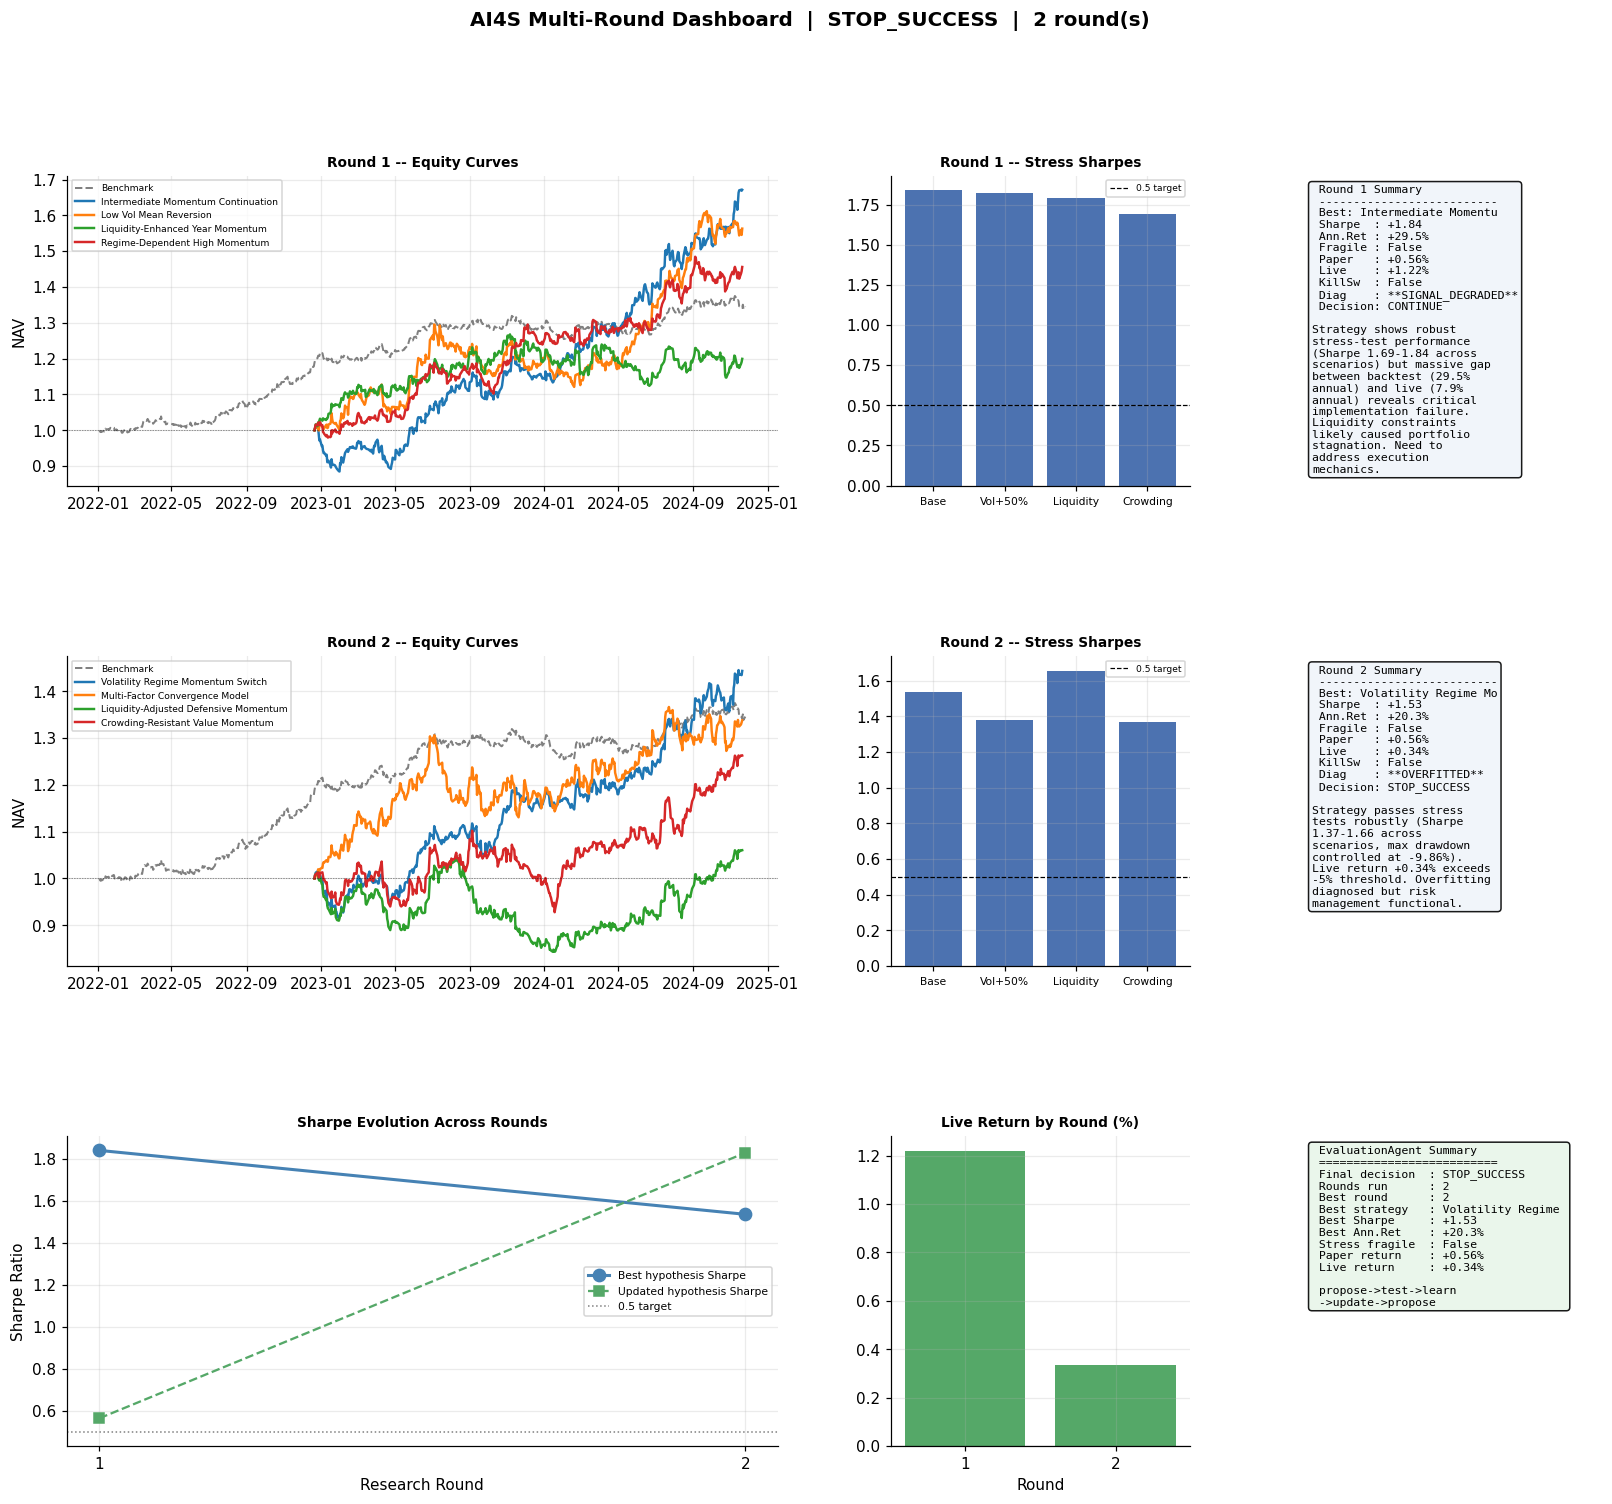

Dashboard saved: ai4s_multiround_dashboard.png


In [6]:
# CELL 6  FINAL MULTI-ROUND DASHBOARD
# -----------------------------------------------------------------------

n_rounds = len(agent.round_results)
colors   = plt.cm.tab10.colors

fig = plt.figure(figsize=(18, 5 * n_rounds + 5))
gs  = gridspec.GridSpec(n_rounds + 1, 4, figure=fig,
                        hspace=0.55, wspace=0.38)

# -- per-round rows ---------------------------------------------------------
for ri, r in enumerate(agent.round_results):
    bm_nav  = r.backtest_results["Benchmark"]["nav"]
    bm_norm = bm_nav / bm_nav.iloc[0]
    dec_entry = next((d for d in agent.decision_log
                      if d["round"] == r.cycle_num), {})
    decision  = dec_entry.get("decision", "N/A")
    reasoning = dec_entry.get("reasoning", "")

    # equity curves
    axA = fig.add_subplot(gs[ri, :2])
    axA.plot(bm_norm.index, bm_norm.values,
             color="grey", lw=1.3, ls="--", label="Benchmark", zorder=2)
    for i, h in enumerate(r.hypotheses):
        nav = r.backtest_results[h["name"]]["nav"]
        axA.plot(nav.index, (nav/nav.iloc[0]).values,
                 lw=1.6, color=colors[i % 10], label=h["name"])
    axA.axhline(1.0, color="black", lw=0.4, ls=":")
    axA.set_title(f"Round {r.cycle_num} -- Equity Curves",
                  fontweight="bold", fontsize=9)
    axA.set_ylabel("NAV")
    axA.legend(fontsize=6)

    # stress Sharpe bars
    axB = fig.add_subplot(gs[ri, 2])
    sc_labels  = ["Base", "Vol+50%", "Liquidity", "Crowding"]
    sc_sharpes = [r.base_stats["sharpe"],
                  r.stress_stats["a"]["sharpe"],
                  r.stress_stats["b"]["sharpe"],
                  r.stress_stats["c"]["sharpe"]]
    bar_c = ["#4C72B0" if s > 0 else "#C44E52" for s in sc_sharpes]
    axB.bar(sc_labels, sc_sharpes, color=bar_c)
    axB.axhline(0.5, color="black", ls="--", lw=0.8, label="0.5 target")
    axB.axhline(0.0, color="crimson", ls="-",  lw=0.6)
    axB.set_title(f"Round {r.cycle_num} -- Stress Sharpes",
                  fontweight="bold", fontsize=9)
    axB.tick_params(axis="x", labelsize=7)
    axB.legend(fontsize=6)

    # round summary text
    axC = fig.add_subplot(gs[ri, 3])
    axC.axis("off")
    diag = r.feedback_verdict.splitlines()[-1] if r.feedback_verdict else "N/A"
    txt_lines = [
        f" Round {r.cycle_num} Summary",
        " " + "-"*26,
        f" Best: {r.best_name[:20]}",
        f" Sharpe  : {r.base_stats['sharpe']:+.2f}",
        f" Ann.Ret : {r.base_stats['ann_return']:+.1%}",
        f" Fragile : {r.fragile}",
        f" Paper   : {r.paper_ret:+.2%}",
        f" Live    : {r.live_ret:+.2%}",
        f" KillSw  : {r.kill_fired}",
        f" Diag    : {diag}",
        f" Decision: {decision}",
        "",
    ] + textwrap.wrap(reasoning, 26)
    axC.text(0.03, 0.97, "\n".join(txt_lines), transform=axC.transAxes,
             fontsize=7.5, va="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#f0f4fa", alpha=0.9))

# -- summary row ------------------------------------------------------------
rounds  = [r.cycle_num for r in agent.round_results]
sharpes = [r.base_stats["sharpe"] for r in agent.round_results]
upd_sh  = [r.stats_updated["sharpe"] for r in agent.round_results]

axS1 = fig.add_subplot(gs[n_rounds, :2])
axS1.plot(rounds, sharpes, "o-", color="steelblue",
          lw=2, ms=8, label="Best hypothesis Sharpe")
axS1.plot(rounds, upd_sh,  "s--", color="#55A868",
          lw=1.5, ms=7, label="Updated hypothesis Sharpe")
axS1.axhline(0.5, color="grey", ls=":", lw=1, label="0.5 target")
axS1.set_xticks(rounds)
axS1.set_xlabel("Research Round")
axS1.set_ylabel("Sharpe Ratio")
axS1.set_title("Sharpe Evolution Across Rounds", fontweight="bold", fontsize=9)
axS1.legend(fontsize=7)

axS2 = fig.add_subplot(gs[n_rounds, 2])
live_rets = [r.live_ret * 100 for r in agent.round_results]
bar_c2    = ["#55A868" if x >= 0 else "#C44E52" for x in live_rets]
axS2.bar(rounds, live_rets, color=bar_c2)
axS2.axhline(0, color="black", lw=0.7)
axS2.set_xticks(rounds)
axS2.set_title("Live Return by Round (%)", fontweight="bold", fontsize=9)
axS2.set_xlabel("Round")

axS3 = fig.add_subplot(gs[n_rounds, 3])
axS3.axis("off")
br = best_result
verdict_lines = [
    " EvaluationAgent Summary",
    " " + "="*26,
    f" Final decision  : {agent.final_decision}",
    f" Rounds run      : {n_rounds}",
    f" Best round      : {br.cycle_num}",
    f" Best strategy   : {br.best_name[:18]}",
    f" Best Sharpe     : {br.base_stats['sharpe']:+.2f}",
    f" Best Ann.Ret    : {br.base_stats['ann_return']:+.1%}",
    f" Stress fragile  : {br.fragile}",
    f" Paper return    : {br.paper_ret:+.2%}",
    f" Live return     : {br.live_ret:+.2%}",
    "",
    " propose->test->learn",
    " ->update->propose",
]
axS3.text(0.03, 0.97, "\n".join(verdict_lines),
          transform=axS3.transAxes, fontsize=7.5, va="top",
          fontfamily="monospace",
          bbox=dict(boxstyle="round", facecolor="#e8f5e9", alpha=0.9))

fig.suptitle(
    f"AI4S Multi-Round Dashboard  |  {agent.final_decision}"
    f"  |  {n_rounds} round(s)",
    fontsize=13, fontweight="bold"
)
plt.savefig("ai4s_multiround_dashboard.png", bbox_inches="tight", dpi=130)
plt.show()
print("Dashboard saved: ai4s_multiround_dashboard.png")


##3.CONCLUSIONS

---

* Conclusion

This notebook set out to demonstrate that the AI for Science paradigm is not merely
a metaphor for quantitative finance — it is a precise engineering blueprint, and one
that maps cleanly onto every stage of the professional research pipeline. What began
as an abstract claim in the introduction has, across six cells and up to three
autonomous research cycles, been made concrete: observations become features, features
become ranked signals, signals become testable hypotheses, hypotheses survive or fail
under evidence, and failure becomes the raw material for the next generation of ideas.
The loop closes. The system learns.

* What Was Built

The architecture introduced two self-contained classes connected by a typed data
contract. `AI4SLoop` encapsulates one complete research cycle — from feature
engineering through live deployment and feedback — and returns a `CycleResult`
dataclass that captures every measurable output of that cycle. `EvaluationAgent`
governs the outer loop, accumulating failure context across rounds and consulting
Claude after each cycle to decide, with explicit reasoning, whether the search
should continue or stop. The two classes interact only through `CycleResult` and
the `failure_context` string, which means either component can be replaced, extended,
or unit-tested without touching the other.

This separation is not incidental. It reflects a deliberate design principle
inherited from AI4S itself: the governor of a discovery process should be
decoupled from the mechanics of a single experiment. The `EvaluationAgent` does
not know how a backtest is computed; it knows what the outcome means and what to
do next. That division of labour is what makes the system extensible.

* The Role of the Language Model

Claude plays five distinct roles in this pipeline, each scoped to a specific
reasoning task: hypothesis generation, stress-test interpretation, performance
diagnosis, hypothesis refinement, and the stop-or-continue decision. In every
case the model receives a precisely bounded prompt and is required to return
structured output — a JSON array, a four-class token, a JSON object with enumerated
keys. This is not language model use as a general-purpose oracle. It is language
model use as a **structured reasoning component** in a larger, auditable system.

The most consequential of these roles is the `failure_summary` produced by the
`EvaluationAgent`'s decision call. Unlike a raw Sharpe ratio, a failure summary
is a natural-language diagnosis: it tells the next generation of hypothesis
generation not merely that a number was low, but *why* — and therefore *what kind
of signal to avoid*. This is the mechanism by which the system genuinely learns
across rounds rather than simply trying random alternatives.

* Numerical Honesty

A system that reports impossible numbers is a system that cannot be trusted.
The four-layer safeguard architecture — data generation clip, portfolio return clip,
NAV floor, and statistics clip — is not defensive programming for its own sake.
It reflects the understanding that a language model receiving a `-315%` annual
return as feedback will attempt to reason about it, and that no reasoning built on
an artefactual input can be sound. Clean numbers are a prerequisite for a
functioning feedback loop, not an afterthought.

* Limitations and the Path Forward

The honest assessment is that this notebook is a proof of concept. The synthetic
data-generating process produces plausible cross-sectional structure but does not
replicate survivorship bias, corporate actions, earnings-driven discontinuities,
or the adversarial dynamics of a market populated by other algorithms. The
transaction cost model is a flat approximation of a nonlinear reality. The
three stress scenarios, while representative, do not exhaust the space of market
regimes a live strategy would encounter.

The path forward is incremental but clear. Replace the synthetic data layer with
a real historical price feed. Extend the feature set to include earnings revisions,
options-implied volatility, and order-flow imbalance. Introduce a nonlinear market
impact model calibrated to position size and average daily volume. Run the
`EvaluationAgent` across a longer history of out-of-sample periods, not just a
single simulated deployment window. And subject every Claude-generated hypothesis
to causal scrutiny — not just statistical testing — before any capital touches it.

* The Deeper Point

Algorithmic trading has long been practised as a form of pattern mining: find
something that worked historically, apply it forward, and hope the pattern persists.
The AI4S framework reframes that activity as a form of disciplined scientific
inquiry. The question is not whether a signal backtests well. The question is
whether there is a *mechanism* — a persistent market structure — that explains
why the signal works, whether that mechanism survives stress, and whether the
system can recognise when it has stopped working and update accordingly.

That reframing does not make the problem easier. It makes it more honest. And
a more honest research process, even one that finds fewer deployable strategies,
is a better foundation for any quantitative programme than one that mistakes
in-sample correlation for out-of-sample edge.

The loop proposed here — propose, test, learn, update, propose again — is
not a guarantee of alpha. It is a guarantee of discipline.
